# Competitors: Bedashing's share among premium substitutes

The third part of the market model (structure in `market_size.ipynb`, catchments in
`catchments.ipynb`). For each lounge we pick the salons a Bedashing customer would realistically
choose instead, and estimate the lounge's **capture** of that premium market.

Data: `data/seed/v3/salons.csv` and `lounge_candidates.csv` (from `scripts/fetch_salons.py`).

## 1. Design, and why

**Definition.**
1. **Candidates:** women's beauty, hair and nail salons inside the lounge's 15-min catchment.
   Men-only (barbers, "gents"), closed and non-salon places (spas, clinics, shops) are excluded.
   **Other Bedashing lounges in the catchment are candidates too**, so lounges whose catchments
   overlap split their shared demand.
2. **Premium substitutes:** Google prices them *expensive* or *very expensive*; where Google has no
   price (most salons), they have at least the catchment's median review count and a rating of at
   least 4.3.
3. **Top k by Google review count**, k = **20** (10 and 30 as sensitivity).
4. **Capture** = lounge reviews ÷ (lounge reviews + the k substitutes' reviews).
   **Estimated customers** = capture x women 15+ in the catchment; **headroom** = the rest.

This is *share among premium substitutes*, not market penetration: budget salons and the long
tail are left out on purpose.

**Why top k, not every salon:** a shopper choosing Bedashing compares it with similar places, and
counting every salon would need ~2,100 Google calls (~$15-60) instead of 576 (free).

**How the candidates were found, and why that way.** No Google search ranks by review count.
We tested four ways of finding each lounge's most-reviewed premium salons against a fully swept
~8 km tile around Al Barsha (recall of the true top 20):

| Method | Calls | Recall of the true top 20 |
|---|---|---|
| One text search ("beauty salon", "ladies salon") over the whole catchment | 6 per lounge | 0-2 / 20 |
| One Nearby search ranked by popularity, 4-8 km radius | 1 | 5 / 20 |
| Both merged | | 5 / 20 |
| **Small Nearby popularity circles (1.5 km) tiling the area** | 14 for the tile | **17 / 20** |

Over a large area Google favours keyword matches or its own popularity blend; locally, popularity
finds the most-reviewed salons. The final run used **1.8 km** circles (576 calls, inside the free
tier; 1.5 km would have needed 770). Section 3 re-measures recall on the actual run.

## 2. Assumptions used here

| Assumption | Value | Evidence / reasoning |
|---|---|---|
| Catchment | 15-min drive (10/20 as sensitivity) | `catchments.ipynb`, `SOURCES.md` |
| Premium: priced | Google `priceLevel` expensive or very expensive | Crowd-sourced spend per person; Bedashing assumed *expensive* (Google has no price for its lounges) |
| Premium: unpriced stand-in | reviews ≥ catchment median and rating ≥ 4.3 | Only ~20% of Dubai salons have a Google price; priced-premium salons had 2x the median reviews (probe) |
| k | **20** (10 / 30) | Reviews are concentrated in thin markets, spread out in dense ones (section 6) |
| Weight | Lifetime Google review count | Revealed preference; older salons are favoured (stated limitation) |
| Excluded from market measures | `zayed-international-airport` | Serves travellers, not its catchment |

In [1]:
%matplotlib inline
import glob
import json
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from matplotlib.patches import Patch
from shapely import make_valid
from shapely.geometry import Point, shape

from scripts.build_cells import women_15plus
from scripts.fetch_isochrones import polygons, ranges_minutes
from scripts.fetch_salons import dedupe, excluded_reason, premium_substitutes, capture
from scripts.places import to_row

pd.set_option("display.width", 160)
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.2, "grid.color": "#888", "axes.edgecolor": "#999", "font.size": 9})
BLUE, ORANGE, AQUA, YELLOW, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#9e9e9e"
EMIRATES = ["Abu Dhabi", "Dubai", "Sharjah", "Ras Al Khaimah", "Fujairah"]
COLOR = dict(zip(EMIRATES, [BLUE, ORANGE, AQUA, YELLOW, "#e87ba4"]))

V3 = ROOT / "data/seed/v3"
A = yaml.safe_load(open(ROOT / "data/scenarios/baseline.yaml"))["assumptions"]
K, MIN_RATING, PRICES = A["competitor_k"], A["premium_min_rating"], A["comparable_price_levels"]
EXCLUDE = {"zayed-international-airport"}
branches = pd.read_csv(V3 / "branches.csv").set_index("branch_id")
salons = pd.read_csv(V3 / "salons.csv")
cand = pd.read_csv(V3 / "lounge_candidates.csv")
cells = pd.read_csv(V3 / "cells.csv").set_index("cell_id")
emirates = pd.read_csv(V3 / "emirates.csv").set_index("emirate")
cells["women"] = women_15plus(cells, emirates, A["worker_housing_female_share"]["medium"])
catch = pd.read_csv(V3 / "catchment_cells.csv")
women = (catch[catch.level == "medium"].merge(cells[["women"]], left_on="cell_id", right_index=True)
         .groupby("branch_id").women.sum())

def as_dicts(df):
    d = df.assign(price_level=df.price_level.fillna(""), rating=df.rating.astype(object).where(df.rating.notna(), None),
                  review_count=df.review_count.fillna(0))
    return d.to_dict("records")

by_lounge = {b: as_dicts(salons[salons.place_id.isin(g.place_id)]) for b, g in cand.groupby("branch_id")}
print(f"{len(salons):,} salons, {(salons.excluded_reason.isna()).sum():,} candidates, {len(cand):,} lounge-candidate pairs; "
      f"k = {K}, min rating {MIN_RATING}, premium prices {PRICES}")

4,237 salons, 2,824 candidates, 5,903 lounge-candidate pairs; k = {'low': 10, 'medium': 20, 'high': 30}, min rating 4.3, premium prices ['expensive', 'very_expensive']


## 3. Recall check on the actual run (Al Barsha probe tile)

In [2]:
r = branches.loc["al-barsha"]
L = A["travel_time_minutes"]
poly = make_valid(shape(polygons(r.lat, r.lng, ranges_minutes(L), A["isochrone_depart_at"])[L["medium"]]))
in_tile = lambda p: abs(p["lat"] - r.lat) <= 0.04 and abs(p["lng"] - r.lng) <= 0.04 and poly.contains(Point(p["lng"], p["lat"]))
probe = dedupe([to_row(p) for f in glob.glob(str(ROOT / "data/raw/places_cache/[0-9a-f]*.json")) for p in json.load(open(f))])
truth_pool = [p for p in probe if in_tile(p) and not excluded_reason(p) and p["place_id"] != r.place_id]
ours = [p for p in by_lounge["al-barsha"] if in_tile(p)]
rows = []
for k in K.values():
    truth = {p["place_id"] for p in premium_substitutes(truth_pool, k, MIN_RATING, PRICES)}
    got = {p["place_id"] for p in premium_substitutes(ours, k, MIN_RATING, PRICES)}
    rows.append({"k": k, "recall": f"{len(truth & got)}/{len(truth)}"})
print(f"probe sweep: {len(truth_pool)} women's salons in tile+catchment; our run: {len(ours)}")
pd.DataFrame(rows).set_index("k").T

probe sweep: 352 women's salons in tile+catchment; our run: 123


k,10,20,30
recall,8/10,17/20,25/30


## 4. Candidates per lounge

In [3]:
print("excluded:", salons.excluded_reason.value_counts().to_dict())
per = cand.groupby("branch_id").size().rename("candidates").to_frame()
for lvl, k in K.items():
    per[f"premium_top{k}"] = [len(premium_substitutes(by_lounge.get(b, []), k, MIN_RATING, PRICES)) for b in per.index]
per["premium_all"] = [len(premium_substitutes(by_lounge.get(b, []), 10_000, MIN_RATING, PRICES)) for b in per.index]
per["priced_share"] = [np.mean([bool(c["price_level"]) for c in by_lounge.get(b, [])]) for b in per.index]
per["emirate"] = branches.emirate
per.sort_values("candidates", ascending=False).round(2)

excluded: {'men-only': 1337, 'not-operational': 44, 'not-a-salon': 32}


,candidates,premium_top10,premium_top20,premium_top30,premium_all,priced_share,emirate
branch_id,,,,,,,
al-barsha,507,10,20,30,220,0.41,Dubai
city-walk,465,10,20,30,184,0.39,Dubai
zawaya-walk,370,10,20,30,93,0.42,Sharjah
delma,360,10,20,30,114,0.41,Abu Dhabi
nad-al-sheba,348,10,20,30,118,0.45,Dubai
ministries-complex,329,10,20,30,96,0.42,Abu Dhabi
khaleej-al-arabi,324,10,20,30,100,0.39,Abu Dhabi
al-maqta,305,10,20,30,88,0.37,Abu Dhabi
mirdif-35,300,10,20,30,85,0.43,Dubai


## 5. Capture at k = 10 / 20 / 30

In [4]:
def lounge_table(k):
    out = []
    for b, row in branches.iterrows():
        subs = premium_substitutes(by_lounge.get(b, []), k, MIN_RATING, PRICES)
        all_rev = sum(c["review_count"] for c in by_lounge.get(b, []))
        sub_rev = sum(s["review_count"] for s in subs)
        out.append({"branch_id": b, "reviews": row.review_count, "capture": capture(row.review_count, subs),
                    "substitutes": len(subs), "coverage": sub_rev / all_rev if all_rev else np.nan,
                    "rank": 1 + sum(s["review_count"] > row.review_count for s in subs),
                    "bedashing_in_set": sum(bool(s.get("is_bedashing")) for s in subs)})
    return pd.DataFrame(out).set_index("branch_id")

tables = {k: lounge_table(k) for k in K.values()}
t = tables[K["medium"]].copy()
for lvl, k in K.items():
    t[f"capture_k{k}"] = tables[k].capture
t["women_catchment"] = women.reindex(t.index).fillna(0)
t["est_customers"] = t[f"capture_k{K['medium']}"] * t.women_catchment
t["headroom"] = t.women_catchment - t.est_customers
t["emirate"] = branches.emirate
t.loc[list(EXCLUDE), ["est_customers", "headroom"]] = np.nan
t["thin_premium_market"] = t.substitutes < K["medium"]   # capture is a share of a tiny pool
t.sort_values(f"capture_k{K['medium']}", ascending=False)[
    [f"capture_k{k}" for k in K.values()] + ["coverage", "rank", "substitutes", "bedashing_in_set",
                                             "women_catchment", "est_customers", "headroom", "thin_premium_market", "emirate"]].round(3)

,capture_k10,capture_k20,capture_k30,coverage,rank,substitutes,bedashing_in_set,women_catchment,est_customers,headroom,thin_premium_market,emirate
branch_id,,,,,,,,,,,,
al-dhafra,0.627,0.627,0.627,0.463,1,7,0,22927.304,14364.576,8562.728,True,Abu Dhabi
al-falah,0.490,0.490,0.490,0.182,1,6,0,49946.829,24496.872,25449.957,True,Abu Dhabi
khalifa-city-a,0.189,0.137,0.115,0.358,1,20,4,91431.593,12497.442,78934.151,False,Abu Dhabi
al-ain,0.179,0.123,0.103,0.399,1,20,0,102438.955,12563.179,89875.776,False,Abu Dhabi
ras-al-khaimah,0.145,0.121,0.110,0.378,2,20,0,55839.696,6774.830,49064.866,False,Ras Al Khaimah
al-taif-mall,0.131,0.111,0.103,0.656,2,20,0,44817.810,4959.877,39857.933,False,Fujairah
khaleej-al-arabi,0.134,0.096,0.079,0.276,2,20,0,69366.590,6674.697,62691.893,False,Abu Dhabi
shakhbout-city,0.123,0.088,0.076,0.377,2,20,1,134563.906,11846.002,122717.904,False,Abu Dhabi
baniyas,0.093,0.075,0.068,0.398,6,20,1,106825.818,7971.905,98853.913,False,Abu Dhabi


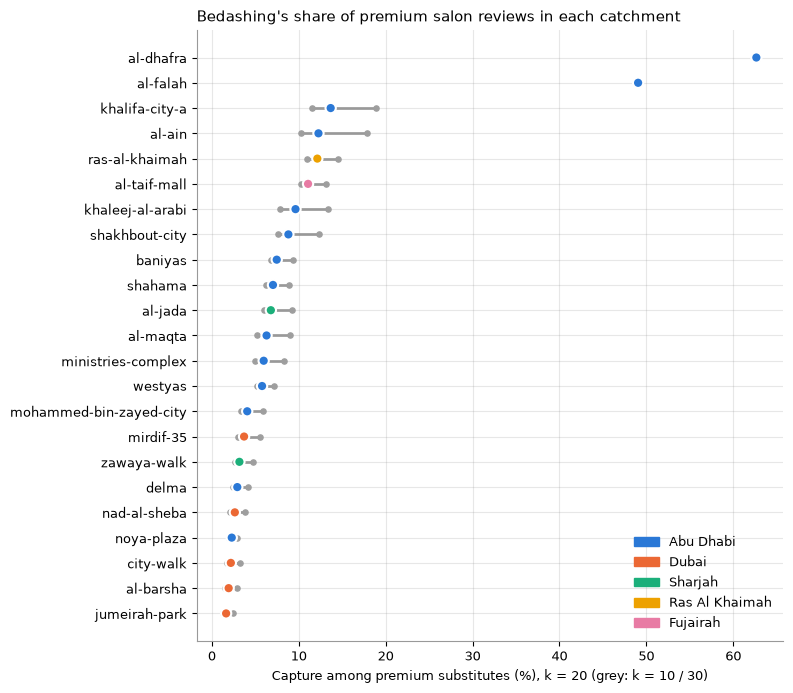

In [5]:
s = t.drop(index=list(EXCLUDE)).sort_values(f"capture_k{K['medium']}")
fig, ax = plt.subplots(figsize=(8, 7))
y = np.arange(len(s))
lo, mid, hi = (s[f"capture_k{k}"] * 100 for k in (K["low"], K["medium"], K["high"]))
ax.hlines(y, np.minimum(lo, hi), np.maximum(lo, hi), color=GREY, lw=2, zorder=1)
ax.scatter(mid, y, s=55, color=[COLOR[e] for e in s.emirate], edgecolor="white", lw=1.5, zorder=3)
ax.scatter(lo, y, s=14, color=GREY, zorder=2); ax.scatter(hi, y, s=14, color=GREY, zorder=2)
ax.set_yticks(y, s.index)
ax.set_xlabel(f"Capture among premium substitutes (%), k = {K['medium']} (grey: k = {K['low']} / {K['high']})")
ax.set_title("Bedashing's share of premium salon reviews in each catchment", loc="left")
ax.legend(handles=[Patch(color=COLOR[e], label=e) for e in EMIRATES], frameon=False, loc="lower right")
plt.tight_layout(); plt.show()

## 6. The dense-market bias, measured
**Coverage** = the share of all candidate reviews in the catchment that the k substitutes hold. Low
coverage means the top k leave much of the market out. Capture is a share of the *premium* set, so
it overstates the lounge's share of the *whole* market most where coverage is lowest. In dense
Dubai catchments, though, the top 20 are also very large salons, so capture there is low anyway.

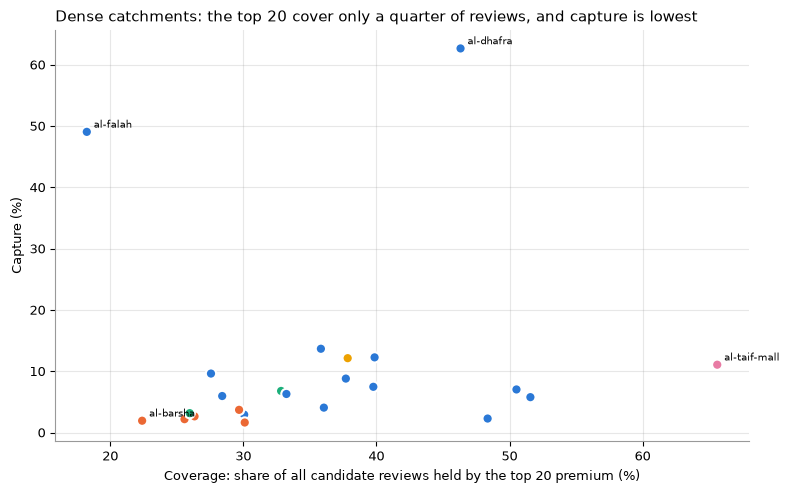

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
d = t.drop(index=list(EXCLUDE))
ax.scatter(d.coverage * 100, d[f"capture_k{K['medium']}"] * 100, s=55, color=[COLOR[e] for e in d.emirate],
           edgecolor="white", lw=1.5, zorder=3)
for b, r in d.iterrows():
    if r.coverage < 0.25 or r.coverage > 0.6 or r[f"capture_k{K['medium']}"] > 0.15:
        ax.annotate(b, (r.coverage * 100, r[f"capture_k{K['medium']}"] * 100), xytext=(5, 3), textcoords="offset points", fontsize=7)
ax.set_xlabel(f"Coverage: share of all candidate reviews held by the top {K['medium']} premium (%)")
ax.set_ylabel("Capture (%)")
ax.set_title("Dense catchments: the top 20 cover only a quarter of reviews, and capture is lowest", loc="left")
plt.tight_layout(); plt.show()

## 7. Who Bedashing competes with

In [7]:
def top_names(b, n=8):
    subs = premium_substitutes(by_lounge.get(b, []), K["medium"], MIN_RATING, PRICES)
    return ", ".join(f"{s['name'][:28]} ({int(s['review_count'])})" for s in subs[:n])
for b in ["al-barsha", "city-walk", "mirdif-35", "khalifa-city-a", "al-ain", "al-dhafra"]:
    print(f"{b} ({int(branches.loc[b, 'review_count'])} reviews): {top_names(b)}\n")

al-barsha (753 reviews): It's Beauty (3219), Ivy The Palm Beauty & Bubble (2994), Its Beauty Ladies Salon – In (2868), Ivy Beauty & Bubbles Hotel I (2738), Its Beauty Ladies Salon – Bu (2666), BROWZ (2573), Ivy Beauty & Bubbles Hub Mar (2346), Elata Beauty Salon - Jumeira (2205)

city-walk (857 reviews): Ivy Beauty & Bubbles Sherato (4487), Ivy Beauty & Bubbles Hotel I (2738), Its Beauty Ladies Salon – Bu (2666), BROWZ (2573), Ashtamudi Ladies Salon BurJu (2406), Ivy Beauty & Bubbles Hub Mar (2346), Hadi beauty Salon (2247), Elata Beauty Salon - Jumeira (2205)

mirdif-35 (817 reviews): Ashtamudi Ladies Beauty Salo (2025), مركز حلا الشام للتجميل - ند  (1868), Beauty Room Salon & Spa (1587), Juice Salon Mirdif (1559), Grand Flora Beauty Salon & S (1362), Salon Afrina Beauty & Henna  (1333), Sisters Beauty Lounge Hair S (1149), CARE SECRETS THERAPY CENTER  (1024)

khalifa-city-a (2465 reviews): hair and nail beauty salon (2040), Bedashing Beauty Lounge Al M (1295), Bedashing Beauty Lounge

## 8. Findings

**The competitor set is sound.** On the fully swept Al Barsha tile, the 1.8 km popularity circles
recover 8/10, 17/20 and 25/30 of the true top premium salons by reviews. 4,237 salons were fetched
for 576 Google calls (free tier); 2,824 remain as candidates after removing men-only (1,337,
including Arabic-named barbers and men's salons), closed (44) and non-salon (32) places.

**Capture (k = 20), Bedashing's share of premium-salon reviews in each 15-min catchment:**
- **Strong, where Bedashing leads its premium set:** khalifa-city-a 14% (rank 1 of its set, and the
  network's most-reviewed lounge), al-ain 12% (rank 1), ras-al-khaimah 12% (rank 2), al-taif-mall
  11%, khaleej-al-arabi 10%, shakhbout-city 9%.
- **Weak, in dense Dubai and central Abu Dhabi:** jumeirah-park 2%, al-barsha 2%, city-walk 2%,
  noya-plaza 2%, nad-al-sheba 3%, delma 3%, zawaya-walk 3%, mirdif-35 4%. In jumeirah-park,
  al-barsha, city-walk and nad-al-sheba **Bedashing isn't in its own catchment's top 20 premium
  salons**: the set is led by
  salons and chains with 2,000-4,500 reviews (Ivy Beauty & Bubbles, It's Beauty, BROWZ, Elata).
- **Unreliable: al-dhafra 63% and al-falah 49%.** Only 6-7 salons qualify as premium there, so
  capture is a share of a tiny pool (flagged `thin_premium_market`).
- **k matters most where Bedashing is strong:** khalifa-city-a is 19% at k = 10 and 12% at k = 30;
  in Dubai the range is under 3 points (mirdif-35 6% → 3%).

**The dense-market bias is visible:** in the dense centres the top 20 hold only 22-30% of all
candidate reviews (all five Dubai lounges, al-barsha 22%; Abu Dhabi's delma, khaleej-al-arabi and
ministries-complex 28-30%; Sharjah's zawaya-walk 26%), against 33-66% elsewhere. There, capture is
a share of the premium end only; Bedashing's share of the whole market is lower still.

**Cannibalisation shows up in the sets:** most Abu Dhabi city lounges have 3-5 other Bedashing
lounges among their top 20 substitutes (mohammed-bin-zayed-city 5; khalifa-city-a, shahama and the
airport lounge 4; baniyas and shakhbout-city 1; khaleej-al-arabi none). The two Sharjah lounges
appear in each other's sets. Dubai lounges have none: there the top 20 are bigger, busier salons.

**Estimated customers (capture x women 15+ in the catchment)** run from ~1k (noya-plaza) to ~14k
(al-dhafra, unreliable) and ~12.5k (khalifa-city-a, al-ain). Treat them as an order of magnitude:
reviews-per-customer differs between salons, and the review counts are lifetime totals.